In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
pd.set_option("display.max_columns", None)

C:\Users\prajin\PycharmProjects\Explainable-Sepsis-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load("../models/sepsis_progression_lightgbm_best.pkl")
print("model type:", type(model))

model type: <class 'lightgbm.sklearn.LGBMClassifier'>


In [3]:
print("Number of features:", model.n_features_in_)
print("Number of classes:", len(model.classes_))
print("Classes:", model.classes_)

Number of features: 103
Number of classes: 3
Classes: [0 1 2]


In [6]:
### dataset for testing
test_dataset = pd.read_csv("../data/processed/sepsis_progression_test.csv")
print("test dataset shape", test_dataset.shape)

test dataset shape (64226, 129)


In [7]:
target_column = "progression_class"

raw_lab_cols_replaced = [
    "creatinine", "bun", "wbc", "hemoglobin", "hematocrit", "platelet", "bands",
    "sodium", "potassium", "chloride", "bicarbonate", "calcium", "magnesium",
    "aniongap", "albumin", "bilirubin_total", "bilirubin_max", "inr", "pt", "ptt",
    "crp", "lactate", "glucose_lab", "pao2fio2ratio_novent", "pao2fio2ratio_vent"
]

raw_lab_cols_replaced = [
    c for c in raw_lab_cols_replaced
    if c in test_dataset.columns
]

feature_columns = [
    c for c in test_dataset.columns
    if c != target_column and c not in raw_lab_cols_replaced
]

X_test = test_dataset[feature_columns].copy()
y_test = test_dataset[target_column].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (64226, 103)
y_test shape: (64226,)


In [8]:
### creating shap explainer
explainer = shap.TreeExplainer(model)


In [9]:
### creating shap dataset
X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)
print(" shap dataset:", X_shap.shape)


 shap dataset: (2000, 103)


In [10]:
### calculating shap values
shap_values = explainer.shap_values(X_shap)
print("shap values calculated")
print(" shap value shape", shap_values.shape)

shap values calculated
 shap value shape (2000, 103, 3)


LOCAL SHAP EXPLANATION
Sample index: 111
Actual class: 0 (Improving)
Predicted class: 0 (Improving)

Prediction probabilities:
  Improving: 0.9189 (91.89%)
  Stable: 0.0143 (1.43%)
  Deteriorating: 0.0669 (6.69%)


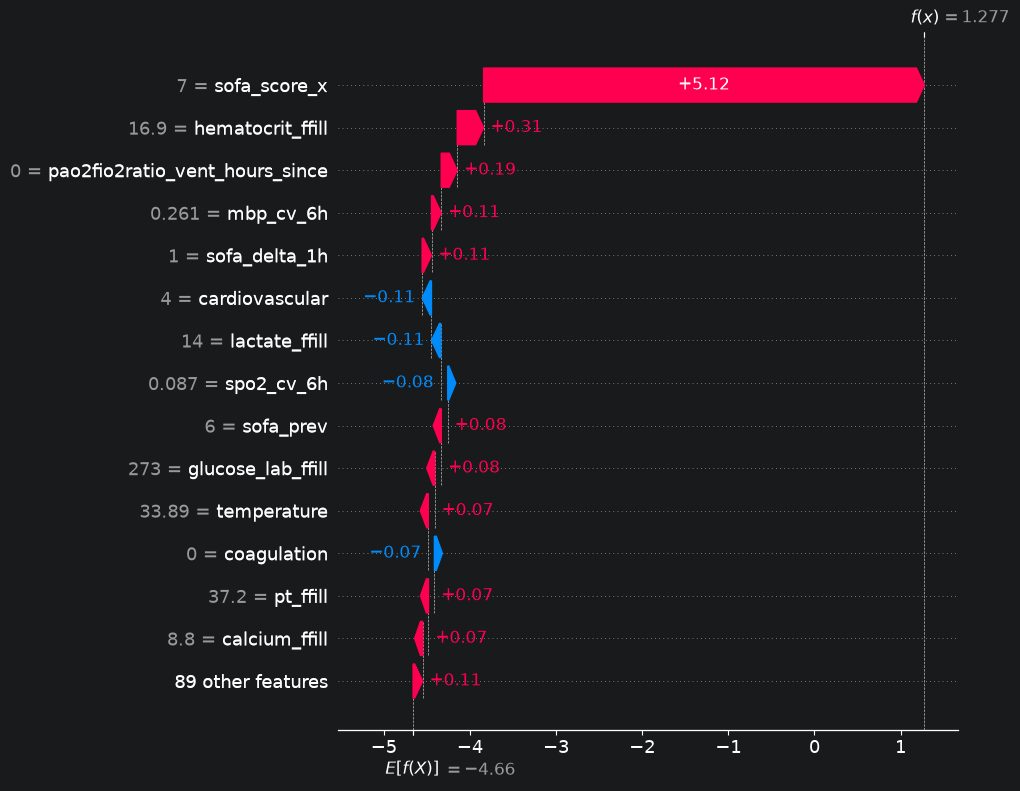

In [14]:
sample_index = 111   # <-- CHANGE THIS INDEX

# Get the sample
X_local = X_test.iloc[[sample_index]]
y_actual = y_test.iloc[sample_index]

# Prediction
prediction = model.predict(X_local)[0]
probabilities = model.predict_proba(X_local)[0]

# Class names
class_names = {
    0: "Improving",
    1: "Stable",
    2: "Deteriorating"
}

# Calculate SHAP values for this sample
shap_local = explainer.shap_values(X_local)

# Select SHAP values for predicted class
if isinstance(shap_local, list):
    shap_local_values = shap_local[prediction]
else:
    shap_local_values = shap_local[:, :, prediction]

# Create SHAP explanation
shap_explanation = shap.Explanation(
    values=shap_local_values[0],
    base_values=explainer.expected_value[prediction],
    data=X_local.iloc[0].values,
    feature_names=X_local.columns
)

# Print results
print("LOCAL SHAP EXPLANATION")


print(f"Sample index: {sample_index}")
print(f"Actual class: {y_actual} ({class_names[y_actual]})")
print(f"Predicted class: {prediction} ({class_names[prediction]})")

print("\nPrediction probabilities:")
for class_index, probability in enumerate(probabilities):
    print(f"  {class_names[class_index]}: {probability:.4f} "
          f"({probability * 100:.2f}%)")

# Show waterfall plot
shap.plots.waterfall(
    shap_explanation,
    max_display=15
)